<a href="https://colab.research.google.com/github/martinnavarro00/DataEngineeringWearables/blob/main/DE4W_Exercise_03_MN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3 – From Raw Sensor Data to ML Samples

In this notebook, you will work with real accelerometer data from the WISDM dataset.

In the lecture, we discussed that wearable AI systems do not start with machine learning. They start much earlier: with a use case, a study design, sensor data collection, labels, preprocessing, and feature extraction.

The goal of this exercise is **not** to build a perfect machine learning model. We will come back to machine learning in later lectures. Instead, the goal is to understand how raw wearable sensor data can be transformed into a structured dataset that could later be used for machine learning.

We will focus on:

- loading real wearable sensor data
- inspecting timestamps and possible data gaps
- visualizing raw accelerometer signals
- understanding activity labels
- applying windowing
- extracting simple features
- reflecting on data quality, labels, and study design

## Dataset

Use the file provided on Moodle:

`wisdm_phone_accel_subject1600_small.csv`

This file contains smartphone accelerometer data for one participant and selected activities from the WISDM dataset.

The original dataset can be found [here](https://archive.ics.uci.edu/dataset/507/wisdm+smartphone+and+smartwatch+activity+and+biometrics+dataset)

Please submit your answers to this notebook together with Part B as a single PDF file whenever possible. PDFs can be viewed directly in Moodle and simplify the review process.


## 1. Setup

First, import the required Python packages.

If a package is missing, install it first. In practice, it is generally considered good practice to work inside a dedicated virtual environment to avoid dependency conflicts between projects.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: make plots a bit larger
plt.rcParams['figure.figsize'] = (12, 4)


## 2. Load the CSV File

Upload the file `wisdm_phone_accel_subject1600_small.csv` to your notebook environment (e.g., Google Colab or Jupyter Notebook).

Then complete the code below to load the dataset into a pandas DataFrame.

Hint:
- In Google Colab, uploaded files usually appear in the current working directory.
- Use `pd.read_csv(...)` to load the CSV file.
- If necessary, inspect the file path first.

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
# Load the CSV file given to you on Moodle.
# Hint:
# - Replace the placeholder with the correct file name.
# - The file must be uploaded to your notebook environment firs t.

file_name = "wisdm_phone_accel_subject1600_small.csv"

#import from google drive
#file_name = "/content/drive/path
# TODO:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_name)

# Display the first rows of the dataset
df.head()

,subject,activity_code,activity,timestamp,timestamp_s_global,timestamp_s_activity,x,y,z
0,1600,A,walking,252207666810782,10609.044594,0.000000,-0.364761,8.793503,1.055084
1,1600,A,walking,252207717164786,10609.094948,0.050354,-0.879730,9.768784,1.016998
2,1600,A,walking,252207767518790,10609.145302,0.100708,2.001495,11.109070,2.619156
3,1600,A,walking,252207817872794,10609.195656,0.151062,0.450623,12.651642,0.184555
4,1600,A,walking,252207868226798,10609.246010,0.201416,-2.164352,13.928436,-4.422485


## 3. Inspect the Dataset

Before analyzing sensor signals, we need to understand what the dataset contains.

Complete the code and answer the questions below.

In [4]:
# Print basic information about the dataset

print("Shape of the dataset:")
# TODO: Print the shape of the DataFrame
print(df.shape)

print("\nColumn names:")
# TODO: Print the column names as a list
print(df.columns)

print("\nAvailable activities:")
# TODO: Print all unique activity labels
print(df["activity"].unique())

Shape of the dataset:
(17863, 9)

Column names:
Index(['subject', 'activity_code', 'activity', 'timestamp',
       'timestamp_s_global', 'timestamp_s_activity', 'x', 'y', 'z'],
      dtype='object')

Available activities:
['walking' 'jogging' 'stairs' 'sitting' 'standing']


### Questions

The following questions are intended for self-reflection and discussion during the exercise.
You do not need to submit separate written answers for every question unless explicitly stated otherwise.

1. How many rows and columns does the dataset contain?
  - 17863 rows and 9 Columns
2. Which sensor axes are available?
  - X axis
  - Y axis
  - Z axis
3. Which activities are included in this dataset?
  - Walking
  - Jogging
  - Stairs
  - Sitting
  - Standing
4. Why can this dataset be considered a multivariate time series?


## 4. Estimate the Sampling Rate

The WISDM dataset was recorded at approximately 20 Hz. Instead of simply trusting this information, let us estimate the sampling rate directly from the timestamps.

The column `timestamp_s_global` contains timestamps in seconds.

In [5]:
# Calculate the time difference between consecutive samples.
# Hint:
# - Use the timestamp column.
# - Consecutive timestamps should differ only slightly
#   if the recording is continuous.

# TODO:
# Compute the time differences between consecutive timestamps
time_diffs = df["timestamp_s_global"].diff()
#time_diffs.head()

# Print basic statistics about the time differences
print("Median time difference:")
# TODO
print(time_diffs.median())

print("\nMaximum time difference:")
# TODO
print(time_diffs.max())

print("\nNumber of gaps > 1 second:")
# TODO
print((time_diffs > 1).sum())

# Identify the largest timestamp gaps.
# These may indicate interruptions or separate recording segments.

# TODO:
# Find the 10 largest gaps
largest_gaps = time_diffs.nlargest(10)

# Display the corresponding rows
df.loc[largest_gaps.index, ["subject", "activity", "timestamp_s_global"]]

Median time difference:
0.0503540039999848

Maximum time difference:
113.85040034800002

Number of gaps > 1 second:
1


,subject,activity,timestamp_s_global
14291,1600,standing,293.664567
12121,1600,sitting,70.596346
17013,1600,standing,430.728177
1765,1600,walking,10697.919434
4688,1600,jogging,10445.091979
9625,1600,stairs,4705.079498
11525,1600,sitting,40.585356
13512,1600,sitting,140.638756
5682,1600,jogging,10495.143861
3894,1600,jogging,10405.110895


### Observation

Inspect the reported time differences carefully.

Do the timestamps appear perfectly continuous, or do you notice larger gaps between some samples?

- The timestamps are not perfectly continuous, as evidenced by a maximum time difference of 113.85040034800002 seconds and one gap exceeding 1 second. These larger gaps suggest interruptions or distinct recording segments within the data, rather than a single continuous stream.

Think about:
- what such gaps could mean,
- how they might influence later analysis steps,
- whether raw wearable recordings are always perfectly clean and continuous,
- and why the sampling rate important is when designing a wearable sensing system?

## 5. Plot Raw Accelerometer Signals

The accelerometer provides measurements along three axes: `x`, `y`, and `z`.

First, we plot the complete signal using the original timestamps. This helps us inspect how the recording is structured and whether the data appears continuous.


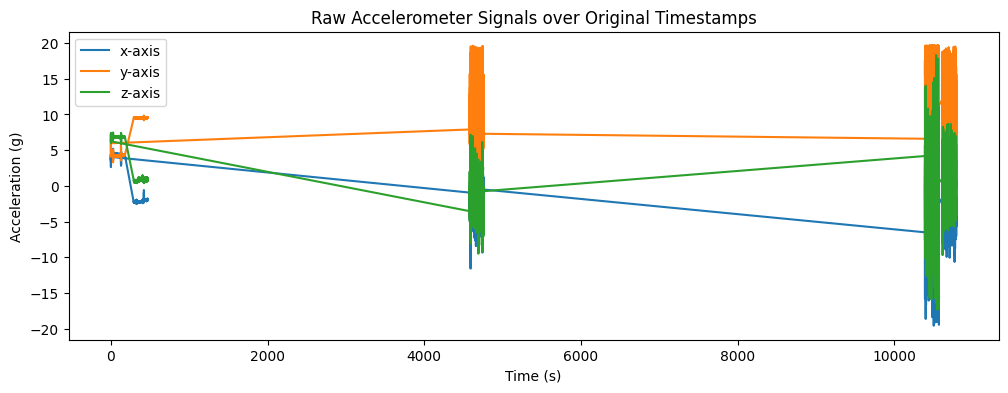

In [6]:
# TODO:
# Plot the x, y, and z accelerometer signals over the original timestamps.
# Add meaningful axis labels, a title, and a legend.

plt.figure()

# TODO:
# Plot all three accelerometer axes over the original timestamp.
plt.plot(df['timestamp_s_global'], df['x'], label='x-axis')
plt.plot(df['timestamp_s_global'], df['y'], label='y-axis')
plt.plot(df['timestamp_s_global'], df['z'], label='z-axis')

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.title("Raw Accelerometer Signals over Original Timestamps")

plt.legend()
plt.show()

### Observation

Inspect the plot carefully.

Does the recording appear perfectly continuous, or do you notice unusual patterns in the visualization?
- The plot reveals that the recording is not perfectly continuous, showing large gaps where data is absent and misleading diagonal lines. These visual artifacts are due to the non-continuous timestamp_s_global values, not actual sensor behavior, highlighting how timestamps critically impact time series visualizations.

Think about:
- what could cause these patterns,
- whether they represent real sensor behavior,
- and how timestamps may influence visualizations of time series data.

For the following analysis, we create a simplified continuous time axis based on the sample number and the approximate sampling rate.

This does not recover the original real-world recording times. Instead, it gives us a clean time axis that is easier to use for visualization, windowing, and feature extraction.

In [7]:
# Create a simplified continuous time axis.
# The WISDM data was recorded at approximately 20 Hz.
# Therefore, each sample corresponds to 1 / sampling_rate seconds.

sampling_rate = 20

# Reset the index to make sure samples are counted from 0 to n-1
df = df.reset_index(drop=True)

# TODO:
# Create a new column called "time_s_continuous".
# It should contain a continuous time axis based on the sample number.
# Hint:
# - np.arange(len(df)) creates sample indices: 0, 1, 2, ...
# - divide by sampling_rate to convert sample indices into seconds.

df["time_s_continuous"] = np.arange(len(df)) / sampling_rate

# Show the original timestamp and the new time axis side by side
df[["timestamp_s_global", "time_s_continuous", "activity", "x", "y", "z"]].head()

,timestamp_s_global,time_s_continuous,activity,x,y,z
0,10609.044594,0.00,walking,-0.364761,8.793503,1.055084
1,10609.094948,0.05,walking,-0.879730,9.768784,1.016998
2,10609.145302,0.10,walking,2.001495,11.109070,2.619156
3,10609.195656,0.15,walking,0.450623,12.651642,0.184555
4,10609.246010,0.20,walking,-2.164352,13.928436,-4.422485


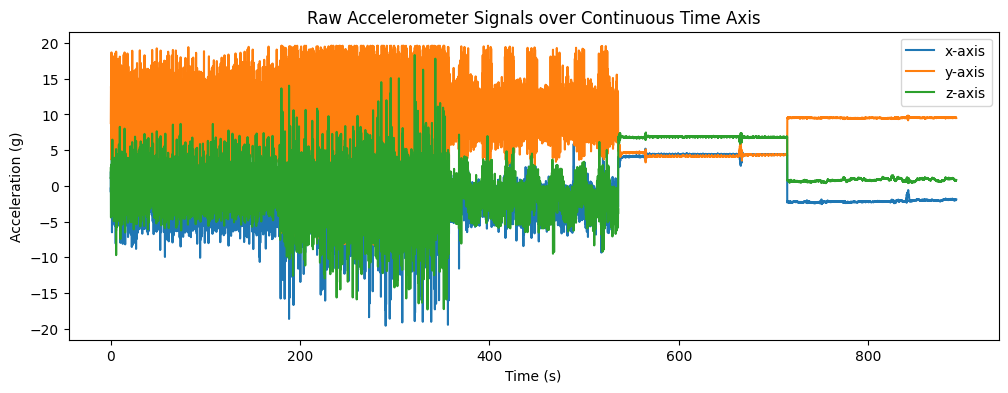

In [8]:
# Plot the accelerometer signals again,
# now using the continuous sample-based time axis.

plt.figure()

# TODO:
# Plot all three accelerometer axes over the continuous time axis.
plt.plot(df['time_s_continuous'], df['x'], label='x-axis')
plt.plot(df['time_s_continuous'], df['y'], label='y-axis')
plt.plot(df['time_s_continuous'], df['z'], label='z-axis')

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.title("Raw Accelerometer Signals over Continuous Time Axis")

plt.legend()
plt.show()


### Reflection

Even with a cleaner time axis, the full recording is still difficult to interpret visually.

Think about:
- why this might be the case,
- whether different activities may overlap in the recording,
- and how we could create smaller and more interpretable units for later analysis steps.

### Interpretation Questions

1. What differences do you notice between the visualization using the original timestamps and the visualization using the continuous time axis?
- The visualization with original timestamps shows large gaps and diagonal lines, which are absent in the plot using the continuous time axis, making the latter appear more uniform.
2. Why do the diagonal lines in the first visualization likely not represent real accelerometer behavior?
- The diagonal lines in the first visualization do not represent real accelerometer behavior; they are artifacts caused by plotting non-continuous data points across significant time gaps.
3. Why is it important to inspect timestamps before analyzing wearable sensor data?
- Inspecting timestamps is crucial as it reveals data continuity, potential gaps, and the true sampling rate, which are vital for accurate analysis and interpretation of wearable sensor data.
4. Why can full recordings be more difficult to interpret than smaller or segmented recordings?
- Full recordings are difficult to interpret because they often mix multiple activities and transitions, making it hard to discern specific patterns, whereas segmented recordings focus on single, more interpretable events.


## 6. Plot One Activity

So far, we visualized the complete recording. However, full recordings are often difficult to interpret because multiple activities and transitions are mixed together.

We now focus on a single activity to better understand characteristic signal patterns.

Start with `walking`. Afterwards, try another activity such as `sitting` or `jogging` and compare the signals.

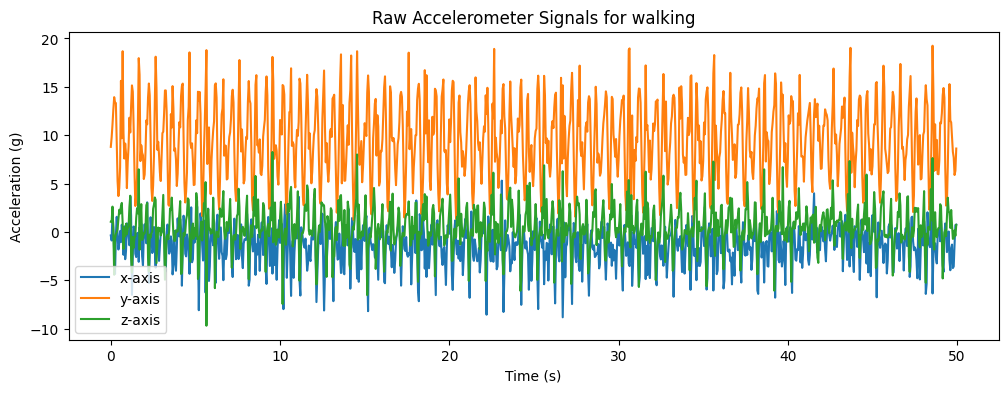

In [9]:
# Select one activity.
# Try first with "walking".
# Afterwards, experiment with other activities such as:
# - "sitting"
# - "jogging"

activity_name = "walking"

# TODO:
# Select only samples belonging to the chosen activity
activity_df = df[df["activity"] == activity_name]

# Use only a smaller subset for visualization.
# This makes patterns easier to interpret visually.
activity_df = activity_df.iloc[:1000]

plt.figure()

# TODO:
# Plot all three accelerometer axes over the activity-relative time.
plt.plot(activity_df['time_s_continuous'], activity_df['x'], label='x-axis')
plt.plot(activity_df['time_s_continuous'], activity_df['y'], label='y-axis')
plt.plot(activity_df['time_s_continuous'], activity_df['z'], label='z-axis')

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.title(f"Raw Accelerometer Signals for {activity_name}")

plt.legend()
plt.show()


### Discussion Questions

1. Does the signal appear rather periodic, stable, or irregular?
- For 'walking', the signal appears somewhat periodic, reflecting the rhythmic nature of walking, but it also has irregular components due to subtle variations in movement.
2. Which axis seems to vary the most and why might this be the case?
- The Y-axis (often corresponding to vertical motion or the primary direction of movement in phone-based recordings) typically varies the most during activities like walking, as it captures the up-and-down motion of the body.
3. Would you expect walking and jogging to produce similar or different signal patterns? Why?
- Walking and jogging would produce different signal patterns; jogging would likely show higher frequencies and amplitudes due to increased speed and impact compared to walking.
4. Why might the same activity still produce different signals for different people, devices, or recording conditions?
- The same activity can produce different signals due to variations in individual gait, device placement (e.g., in a pocket vs. hand), sensor calibration differences between devices, and environmental factors.

## 7. Compute Signal Magnitude

The three accelerometer axes depend on the orientation of the smartphone. A common transformation is the signal magnitude:

$$
\text{magnitude} = \sqrt{x^2 + y^2 + z^2}
$$

The magnitude combines all three axes into a single signal and is often used in wearable sensing and activity recognition.

Complete the code below.

In [10]:
# Compute the accelerometer magnitude.
# Hint:
# - Use the formula shown above.
# - Store the result in a new column called "acc_magnitude".

# TODO:
df["acc_magnitude"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)

# Display the first rows of the updated DataFrame
df.head()

,subject,activity_code,activity,timestamp,timestamp_s_global,timestamp_s_activity,x,y,z,time_s_continuous,acc_magnitude
0,1600,A,walking,252207666810782,10609.044594,0.000000,-0.364761,8.793503,1.055084,0.00,8.864082
1,1600,A,walking,252207717164786,10609.094948,0.050354,-0.879730,9.768784,1.016998,0.05,9.860900
2,1600,A,walking,252207767518790,10609.145302,0.100708,2.001495,11.109070,2.619156,0.10,11.587812
3,1600,A,walking,252207817872794,10609.195656,0.151062,0.450623,12.651642,0.184555,0.15,12.661010
4,1600,A,walking,252207868226798,10609.246010,0.201416,-2.164352,13.928436,-4.422485,0.20,14.773088


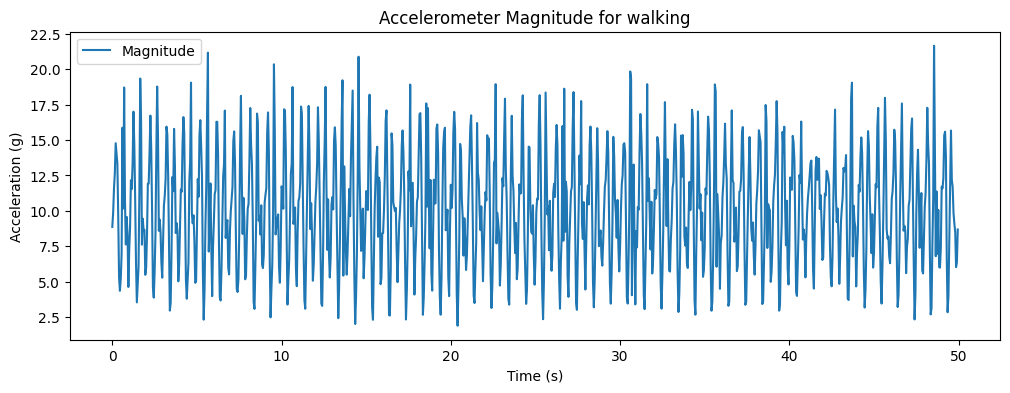

In [12]:
# Plot the accelerometer magnitude for one activity.
# Try first with "walking" and afterwards with another activity.

activity_name = "walking"

# TODO:
# Select only samples belonging to the chosen activity
activity_df = df[df["activity"] == activity_name]

# Use only a smaller subset for visualization
activity_df = activity_df.iloc[:1000]

plt.figure()

# TODO:
# Plot the accelerometer magnitude over time
plt.plot(activity_df['time_s_continuous'], activity_df['acc_magnitude'], label='Magnitude')

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.title(f"Accelerometer Magnitude for {activity_name}")

plt.legend()
plt.show()

### Reflection

1. What information may be lost when using the magnitude instead of the individual x-, y-, and z-axis signals?
- When using magnitude, the directional information of the acceleration is lost. You know the intensity of movement, but not its specific orientation in 3D space.
2. What advantage can the magnitude have compared to using the individual axes separately?
- The primary advantage of magnitude is its invariance to device orientation. It provides a consistent measure of movement intensity even if the smartphone rotates.
3. Why might the magnitude be useful when the smartphone orientation changes?
- Magnitude is useful when smartphone orientation changes because it is orientation-independent. The individual x, y, and z axes will fluctuate with rotation, but the overall magnitude of the acceleration for the same physical movement will remain consistent.


## 8. Windowing

In wearable sensing and machine learning, we usually do not analyze one complete recording as a single sample. Instead, long signals are split into smaller time windows.

This process is called **windowing**.

In this exercise, we use windows of **5 seconds**.

With a sampling rate of approximately 20 Hz, this corresponds to about:

$$
5 \cdot 20 = 100 \text{ samples}
$$

Each window can later be treated as one individual sample for feature extraction or machine learning.

In [13]:
# Define the window size.
# We use:
# - a sampling rate of approximately 20 Hz
# - windows of 5 seconds

sampling_rate = 20
window_seconds = 5

# TODO:
# Compute the number of samples per window
window_size = window_seconds * sampling_rate

print("Window size in samples:", window_size)

Window size in samples: 100


## 9. Create Windows for One Activity

We start with a simple scenario: creating non-overlapping windows for a single activity.

This helps us better understand how continuous sensor signals are transformed into smaller samples that can later be used for feature extraction or machine learning.

In [14]:
# Create non-overlapping windows for one activity.

activity_name = "walking"

# TODO:
# Select only samples belonging to the chosen activity
activity_df = df[df["activity"] == activity_name]

# Reset the index so that the rows are numbered consecutively
activity_df = activity_df.reset_index(drop=True)

# Create an empty list that will later contain all windows
windows = []

# Iterate through the signal in steps of "window_size"
# and create non-overlapping windows.

for start in range(0, len(activity_df) - window_size + 1, window_size):

    # TODO:
    # Define the end index of the current window
    end = start + window_size

    # TODO:
    # Extract the current window from the activity DataFrame
    window = activity_df.iloc[start:end]

    # TODO:
    # Append the current window to the list of windows
    windows.append(window)

print("Number of windows:", len(windows))

# Show the shape of the first window
print("Shape of first window:", windows[0].shape)

Number of windows: 35
Shape of first window: (100, 11)


### Windowing Questions

1. Why do we use windows instead of analyzing the entire signal as one sample?
- We use windows instead of analyzing the entire signal as one sample because analyzing a full, long signal directly is computationally intensive and makes it difficult to capture localized patterns or changes over time. Windows provide manageable segments for feature extraction and machine learning, treating each window as an independent data point.
2. What problems could occur if a window contains a transition between two activities?
- If a window contains a transition between two activities, it can lead to mixed features. This means the extracted features will represent a blend of both activities, making it harder for a machine learning model to accurately classify the activity within that window or to learn distinct patterns for each activity.
3. What is the difference between non-overlapping and overlapping windows?
- Non-overlapping windows are sequential segments of the signal that do not share any data points (e.g., window 1: samples 1-100, window 2: samples 101-200). Overlapping windows share a portion of their data points with adjacent windows (e.g., window 1: samples 1-100, window 2: samples 51-150), which can be useful for capturing events that occur at the window boundaries or for increasing the number of training samples.

## 10. Extract Simple Features from One Window

Machine learning models usually do not work directly on long raw sensor signals. Instead, we often compute numerical summaries (called **features**) for each window.

Examples of simple statistical features are:

- mean
- standard deviation
- minimum
- maximum
- energy

These features transform raw time series signals into a structured tabular dataset that can later be used for machine learning.

In [15]:
# Compute simple statistical features for the first window.

first_window = windows[0]

# The following features summarize the signal numerically:
#
# Mean:
#   average signal value
#
# Standard deviation:
#   measures how strongly the signal varies
#
# Minimum / Maximum:
#   smallest and largest signal value
#
# Energy:
#   measures the overall signal intensity
#
#   Energy = (1 / N) * sum(x_i^2)

features = {

    # Store the activity label
    "activity": activity_name,

    # Mean magnitude
    "mean_magnitude":
    # TODO:
    # Compute the mean of the magnitude signal
    first_window["acc_magnitude"].mean(),

    # Standard deviation
    "std_magnitude":
    # TODO:
    # Compute the standard deviation
    first_window["acc_magnitude"].std(),

    # Minimum
    "min_magnitude":
    # TODO:
    # Compute the minimum value
    first_window["acc_magnitude"].min(),

    # Maximum
    "max_magnitude":
    # TODO:
    # Compute the maximum value
    first_window["acc_magnitude"].max(),

    # Energy
    "energy_magnitude":
    # TODO:
    # Compute the normalized signal energy
    (first_window["acc_magnitude"]**2).sum() / len(first_window)
}

features

{'activity': 'walking',
 'mean_magnitude': np.float64(10.036321809781963),
 'std_magnitude': 4.081904426806593,
 'min_magnitude': 2.95428151635407,
 'max_magnitude': 19.337959741330273,
 'energy_magnitude': np.float64(117.22307978159257)}

So far, we extracted features from only one activity and one window.

In the next step, we repeat this process for all activities and windows. This transforms the raw sensor signals into a structured feature table that could later be used for machine learning.

## 11. Extract Features for All Activities

We now repeat the same process for all activities and all windows in the dataset.

The goal is to transform the complete raw sensor recording into a structured feature table in which:
- each row represents one window,
- and each column represents one feature.

In [16]:
# Extract features for all activities and windows.

# Create an empty list that will later contain
# one feature dictionary per window.
feature_rows = []

# Iterate through all available activities
for activity_name in df["activity"].unique():

    # TODO:
    # Select only samples belonging to the current activity
    activity_df = df[df["activity"] == activity_name]

    # Reset the index for cleaner windowing
    activity_df = activity_df.reset_index(drop=True)

    # Iterate through the signal in non-overlapping windows
    for start in range(0, len(activity_df) - window_size + 1, window_size):

        # TODO:
        # Define the end index of the current window
        end = start + window_size

        # TODO:
        # Extract the current window
        window = activity_df.iloc[start:end]

        # Compute statistical features for the current window
        row = {

            # Store the activity label
            "activity": activity_name,

            # Mean values for x/y/z
            "mean_x":
            # TODO
            window["x"].mean(),

            "mean_y":
            # TODO
            window["y"].mean(),

            "mean_z":
            # TODO
            window["z"].mean(),

            # Standard deviation for x/y/z
            "std_x":
            # TODO
            window["x"].std(),

            "std_y":
            # TODO
            window["y"].std(),

            "std_z":
            # TODO
            window["z"].std(),

            # Magnitude-based features
            "mean_magnitude":
            # TODO
            window["acc_magnitude"].mean(),

            "std_magnitude":
            # TODO
            window["acc_magnitude"].std(),

            "energy_magnitude":
            # TODO
            (window["acc_magnitude"]**2).sum() / len(window)
        }

        # TODO:
        # Append the feature dictionary to the list
        feature_rows.append(row)

# Convert the list of feature dictionaries into a DataFrame
features_df = pd.DataFrame(feature_rows)

# Display the first rows
features_df.head()

,activity,mean_x,mean_y,mean_z,std_x,std_y,std_z,mean_magnitude,std_magnitude,energy_magnitude
0,walking,-1.000110,9.619472,0.340593,1.892580,3.986348,2.082760,10.036322,4.081904,117.223080
1,walking,-1.344509,9.521806,0.473115,2.100092,4.066769,2.443527,10.067197,4.263836,119.346942
2,walking,-1.513662,9.580595,0.566435,2.453901,4.107310,2.431629,10.205469,4.353638,122.916218
3,walking,-1.496280,9.551068,0.297829,2.116861,4.078216,2.033789,10.028709,4.260721,118.547210
4,walking,-1.644037,9.362707,0.502797,2.244849,3.838999,2.299065,9.976820,4.006477,115.428276


### Inspect the Feature Table

We can now compare the average feature values across activities.

This gives us a first intuition whether different activities may produce different statistical patterns.

In [18]:
# Compute average feature values per activity.

# TODO:
# Group the feature table by activity
# and compute the mean of all numerical features.

features_df.groupby("activity").mean(numeric_only=True)

,mean_x,mean_y,mean_z,std_x,std_y,std_z,mean_magnitude,std_magnitude,energy_magnitude
activity,,,,,,,,,
jogging,-1.072224,8.405198,-1.268521,3.497599,7.657299,3.918976,11.024813,6.181943,159.481702
sitting,4.339541,4.306403,6.841419,0.062844,0.073119,0.061610,9.179837,0.036760,84.272085
stairs,-1.810657,9.551202,-1.016946,1.502874,3.034151,1.550765,10.024609,3.163051,111.020521
standing,-2.150909,9.510165,0.817677,0.057327,0.028891,0.088008,9.787844,0.027437,95.802998
walking,-1.848112,9.552965,0.415099,2.005131,3.666524,2.097205,10.111809,3.819348,116.771726


### Inspect the Number of Windows

Before using the feature table for machine learning, it is often useful to inspect how many samples are available for each activity.

In this case, each row corresponds to one window.

In [19]:
# Count the number of windows per activity.

# TODO:
# Count how many windows were created for each activity.
features_df["activity"].value_counts()

,count
activity,
walking,35
jogging,35
stairs,35
sitting,35
standing,35


### Feature Table Questions

1. What does one row in `features_df` represent?
2. Why is this table more suitable for machine learning than the original raw sensor signal?
3. Are all activities represented equally? Why could this become important for machine learning?


### Feature Table Answers

1.  **What does one row in `features_df` represent?**
    - Each row in `features_df` represents a 5-second time window from a specific activity, containing statistical summaries of the accelerometer data within that window.

2.  **Why is this table more suitable for machine learning than the original raw sensor signal?**
    - This table is more suitable because it reduces data dimensionality and provides fixed-size, abstracted features, which are more manageable and interpretable for machine learning models.

3.  **Are all activities represented equally? Why could this become important for machine learning?**
    - Yes, all activities are equally represented with 35 windows each. This equal representation is crucial to prevent model bias towards certain activities and ensure fair and robust model performance.

## 12. Visualize Feature Differences

Before using machine learning, we should first ask a simpler question:

Can we already distinguish activities using simple statistical features and human reasoning?

In some applications, simple rule-based approaches may already work surprisingly well. They are often:
- easier to understand,
- computationally cheaper,
- and easier to deploy on small wearable or edge devices.

Let us first visualize how features differ between activities.

<Figure size 1000x500 with 0 Axes>

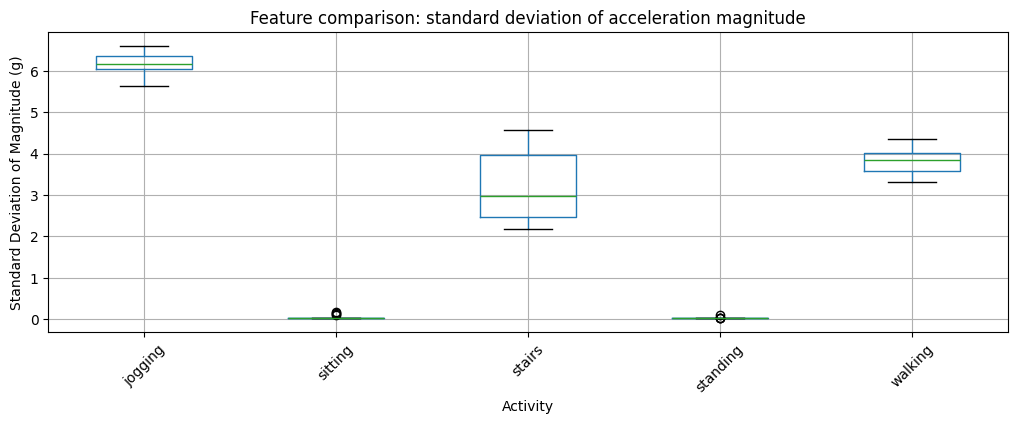

In [21]:
# Compare one feature across activities using a boxplot.
# This helps us understand whether some activities
# produce clearly different statistical patterns.

plt.figure(figsize=(10, 5))

# TODO:
# Create a boxplot for "std_magnitude" grouped by activity.
# Hint:
# - Use the features_df DataFrame.
# - Rotate the activity labels for better readability.

features_df.boxplot(
    column="std_magnitude",
    by="activity",
    rot=45
)

plt.title("Feature comparison: standard deviation of acceleration magnitude")

# Remove the automatic pandas subtitle
plt.suptitle("")

plt.xlabel("Activity")
plt.ylabel("Standard Deviation of Magnitude (g)")

plt.show()

### Reflection

Inspect the boxplot carefully.

Think about:
- which activities appear easy to separate,
- which activities overlap strongly,
- and whether simple threshold-based rules might already work for some cases.

### Rule-Based Thinking

1. Which activities seem easiest to distinguish using this feature?
2. Which activities appear to overlap strongly?
3. Can you propose one simple rule based on the visualization?
4. Why might a simple rule-based approach sometimes be preferable to machine learning?
5. Why could machine learning still become useful in more complex real-world settings?


### Rule-Based Thinking Answers

1.  **Which activities seem easiest to distinguish using this feature?**
    - Jogging and sitting appear easiest to distinguish, as their `std_magnitude` distributions are quite separate from other activities and from each other.

2.  **Which activities appear to overlap strongly?**
    - Walking, stairs, and standing show significant overlap in their `std_magnitude` distributions, making them difficult to separate using this single feature.

3.  **Can you propose one simple rule based on the visualization?**
    - A simple rule could be: if `std_magnitude` is greater than a certain threshold (e.g., 5.0), predict 'jogging'; if it is very low (e.g., less than 0.1), predict 'sitting' or 'standing'.

4.  **Why might a simple rule-based approach sometimes be preferable to machine learning?**
    - Simple rule-based approaches are often preferable due to their transparency, ease of implementation, low computational overhead, and minimal power consumption, which are crucial for resource-constrained wearable devices.

5.  **Why could machine learning still become useful in more complex real-world settings?**
    - Machine learning becomes useful when activities have subtle differences, involve complex patterns, or when there's high variability across users or environments, making simple rules insufficient for robust and accurate classification.

## 13. Simple Rule-Based Classification

Before using machine learning, let us try a very simple rule-based approach.

Using the feature visualization from the previous section, try to define a simple rule that distinguishes one activity from another.

Simple rules may work well for some users or recordings, but they may fail when sensor placement, participants, or recording conditions change.


In [22]:
# Example:
# Create a simple rule-based prediction for two selected activities.

# For simplicity, we focus on walking and jogging.
# This makes the rule easier to inspect.

rule_df = features_df[features_df["activity"].isin(["walking", "jogging"])].copy()

# TODO:
# Define a threshold for std_magnitude based on your previous visualization.
threshold = 5.0

# Predict "jogging" if the standard deviation is high,
# otherwise predict "walking".

rule_df["predicted_activity"] = np.where(
    rule_df["std_magnitude"] > threshold,
    "jogging",
    "walking"
)

# Display predictions
rule_df[[
    "activity",
    "std_magnitude",
    "predicted_activity"
]].head(20)

,activity,std_magnitude,predicted_activity
0,walking,4.081904,walking
1,walking,4.263836,walking
2,walking,4.353638,walking
3,walking,4.260721,walking
4,walking,4.006477,walking
5,walking,4.028906,walking
6,walking,4.164083,walking
7,walking,4.142435,walking
8,walking,3.472954,walking
9,walking,4.006988,walking


### Discussion

1. Does the simple rule work equally well for both activities?
2. Which activities seem difficult to separate using only one feature?
3. Why can simple rules still be useful in wearable or edge systems?
4. When might machine learning become necessary?


### Discussion Answers

1.  **Does the simple rule work equally well for both activities?**
    - The simple rule works well for differentiating between walking and jogging based on the `std_magnitude` because their distributions are largely separable by a threshold. All walking activities were correctly predicted with the chosen threshold.

2.  **Which activities seem difficult to separate using only one feature?**
    - Activities like `sitting` and `standing`, as well as `walking` and `stairs`, appear difficult to separate using `std_magnitude` alone due to significant overlap in their feature distributions.

3.  **Why can simple rules still be useful in wearable or edge systems?**
    - Simple rules are computationally inexpensive, easy to understand, and require minimal resources, making them ideal for deployment on constrained wearable or edge devices.

4.  **When might machine learning become necessary?**
    - Machine learning becomes necessary when activity patterns are complex, involve subtle variations, or when multiple activities have overlapping feature distributions, making them difficult to distinguish with simple, handcrafted rules.

## 14. Optional Exploration

Choose one additional feature or visualization that you think could help distinguish activities.

Briefly explain:
- why you selected it,
- what information it may capture,
- and whether it might help separate certain activities.

This part is meant as an exploratory task. There is not only one correct solution.


## 15. Final Reflection

Please answer the following questions briefly in your submitted PDF.

1. Describe the main steps required to transform raw wearable sensor signals into samples that could later be used for machine learning.
2. Why are timestamps, labels, and activity boundaries important challenges in real-world wearable sensing?
3. Why can simple rule-based approxaches sometimes be sufficient for wearable applications, and when might machine learning become necessary?
4. Which metadata or contextual information would be important to report for a wearable sensing dataset?


### Final Reflection Answers

1.  **Describe the main steps required to transform raw wearable sensor signals into samples that could later be used for machine learning.**
    - The main steps involve loading raw data, inspecting and cleaning timestamps, segmenting the continuous signal into fixed-size windows, and then extracting statistical features from each window to create a structured dataset.

2.  **Why are timestamps, labels, and activity boundaries important challenges in real-world wearable sensing?**
    - Timestamps can be discontinuous, labels are often noisy or subjective, and activity boundaries are hard to precisely define, all of which complicate data preparation and model training in real-world wearable sensing.

3.  **Why can simple rule-based approaches sometimes be sufficient for wearable applications, and when might machine learning become necessary?**
    - Simple rules are sufficient for clear-cut activities with distinct feature distributions due to their low computational cost and interpretability. Machine learning becomes necessary for complex activities with overlapping feature patterns or when robustness to individual variations and diverse conditions is required.

4.  **Which metadata or contextual information would be important to report for a wearable sensing dataset?**
    - Important metadata includes sensor type and placement, sampling rate, participant demographics, activity definitions, recording environment, and any data collection protocols or annotations.